In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Working with Sequences

Until now our models consumed a single feature vector
$\mathbf{x} \in \mathbb{R}^d$, produced a single output,
and assumed that examples were drawn independently
from one common distribution.
This chapter drops both assumptions.
We now work with *sequences*: ordered lists of feature vectors
$\mathbf{x}_1, \dots, \mathbf{x}_T$, where the index
$t \in \mathbb{Z}^+$ is a *time step*
and neighboring entries are anything but independent.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import jax
from jax import numpy as jnp
import numpy as np

## Sequential Data and Its Challenges

Sequences are everywhere once you look for them.
*Text* is a sequence of characters or words, and the word you are
about to read depends on all the words before it;
this is exactly why the auto-complete in your email client
can finish a sentence better than random guessing.
*Audio*, whether speech or music, is a sequence of samples,
or of the spectrogram frames a model actually consumes.
*Time series* such as prices, sensor readings, and patient vitals
arrive one measurement at a time, each shaped by its recent past.

What these have in common, and what sets them apart from the data
of Parts I and II, is dependence.
We still assume that *entire* sequences (a whole document,
a whole patient trajectory) are drawn independently
from a fixed distribution over sequences.
But *within* a sequence the entries are not independent:
the medicine a patient receives on day ten of a hospital stay
depends heavily on the previous nine days.
If the entries were unrelated there would be nothing to predict,
and no reason to treat the data as a sequence in the first place.

Dependence also means that order carries information
and that a sequence's statistics can drift:
a document reads differently at its end than at its beginning,
and a patient's status evolves toward recovery or decline.
We therefore do not assume independence,
or even that the per-step statistics stay fixed over time;
we assume only that whole sequences come from one fixed
distribution over sequences.

Prediction tasks over sequences come in a few shapes.
Sometimes the target is a single label for an entire input sequence
(the sentiment of a movie review),
sometimes a sequence given a fixed input (captioning an image),
and sometimes a sequence given a sequence
(translating a sentence, transcribing speech).
Before handling targets of any kind, we tackle the most basic version:
modeling the sequence itself,
that is, estimating how probable a given sequence is,
$P(\mathbf{x}_1, \ldots, \mathbf{x}_T)$.
Almost everything else in the chapter builds on this.

## Autoregressive Models

Focus on the workhorse case: at each step we predict the next
entry from the ones already seen.
Given a numerical series such as a stock index or a temperature reading,
a forecaster who wants to act on the next step
cares about the conditional distribution

$$P(x_t \mid x_{t-1}, \ldots, x_1).$$

Even when the full distribution is hard to pin down,
a useful summary is the conditional expectation
$\mathbb{E}[x_t \mid x_{t-1}, \ldots, x_1]$,
which we could try to fit with, say,
linear regression (that section).
A model that regresses a signal on its own past
is an *autoregressive model*: features and target
are drawn from the same series.

There is an immediate obstacle.
The number of conditioning inputs $x_{t-1}, \ldots, x_1$
grows with $t$, so if we treat the history as a training set,
every example has a different number of features
and no fixed-input model applies.
Two strategies resolve this,
and they organize not just this section but much of the chapter
(the figure).

### Fixed Windows

The first strategy is to condition only on the last $\tau$ observations
$x_{t-1}, \ldots, x_{t-\tau}$, discarding older history.
Now every example has exactly $\tau$ features (for $t > \tau$),
so any fixed-length model, linear or deep, applies directly.
This is *autoregression* in its narrow sense.

This fixed window is exactly the idea behind the *n-gram*
language models of that section,
where the signal is a stream of words,
and, much later, behind the fixed context window
an attention model reads all at once.
A window is simple and easy to parallelize;
its weakness is a hard horizon,
since anything older than $\tau$ steps is invisible to the model.

### Latent Summaries

The second strategy keeps a running summary $h_t$
of everything seen so far and updates it as new observations arrive.
We predict from the summary, $\hat{x}_t = P(x_t \mid h_t)$,
and refresh it with $h_t = g(h_{t-1}, x_{t-1})$.
Because $h_t$ is never observed directly,
this is a *latent autoregressive model*.
The state $h_t$ has fixed size no matter how long the history,
so the whole unbounded past is compressed into bounded memory.

This latent-state picture is exactly the recurrent neural network
we build in that section, and, in a linearized form,
the state space models of that section.
The entire arc of the next two chapters answers one question
the diagram raises: what should the state $h_t$ remember,
and how should it be updated?

![Two ways to give a sequence model a fixed-size input. (left) Autoregression conditions on a sliding window of the last $\tau$ observations and discards the rest. (right) Latent autoregression carries a recurrent state $h_t$ that summarizes the whole past in fixed size.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rnn-ar-vs-latent.svg)

### From Conditionals to Sequences

Whichever strategy we pick, the per-step conditionals compose
into a model of the whole sequence.
By the chain rule of probability,

$$P(x_1, \ldots, x_T) = P(x_1) \prod_{t=2}^T P(x_t \mid x_{t-1}, \ldots, x_1),$$

so an autoregressive model of the next entry
is automatically a model of the entire sequence:
to score a sequence, multiply the conditionals;
to generate one, sample them left to right.
When the entries are discrete tokens,
each conditional is a classifier over the vocabulary,
and estimating $P(x_1, \ldots, x_T)$ is exactly
*language modeling* (that section).
For now we keep the values continuous and focus on prediction.

## Markov Models and Stationarity

The fixed-window strategy carries a hidden assumption worth naming.

### The Markov Condition

When conditioning on the last $\tau$ steps loses no predictive power
relative to the full history, we say the sequence satisfies
a *Markov condition*: the future is conditionally independent
of the distant past given the recent past.
With $\tau = 1$ the series follows a *first-order* Markov model,
and with $\tau = k$ a $k^{\textrm{th}}$-order one.
Under the first-order condition the joint factorization
collapses to a product over adjacent pairs:

$$P(x_1, \ldots, x_T) = P(x_1) \prod_{t=2}^T P(x_t \mid x_{t-1}).$$

In practice the Markov condition rarely holds exactly.
Real text keeps yielding information as we widen the context,
but with sharply diminishing returns,
so it is often worth pretending a $k^{\textrm{th}}$-order condition
holds in order to buy computational and statistical tractability.
Even today's large language models condition on at most
thousands of tokens at a time, not their entire training history.
For discrete data the simplest such model just counts:
$P(x_t \mid x_{t-1})$ is estimated by the relative frequency
of each successor, an idea we take up again
for n-grams in that section.

### Stationarity

Fitting any of these models presupposes that the *rule* generating
each entry from its predecessors does not itself change over time.
Dynamics with this property are called *stationary*.
The values still change, sometimes dramatically;
what stays put is the conditional law
$P(x_t \mid x_{t-1}, \ldots)$.
Stationarity is what lets us pool examples from different parts
of one sequence, or from many sequences, into a single training set,
and it is why we build training data by sampling windows.

One choice above was implicit: we factored the sequence left to right.
Any order gives a valid factorization,
but for causal data the forward direction is usually easier to learn,
since predicting an effect from its cause tends to be simpler
than the reverse [@Peters.Janzing.Scholkopf.2017].
As we generally want to predict the future from the past anyway,
left to right it is.

## Training

Enough theory; let us fit an autoregressive model.
We work first with continuous synthetic data,
where we control the ground truth.
We draw 1000 points from the sine of 0.01 times the time step,
corrupt each with additive noise,
and carve training examples out of the result.

In [2]:
class Data(d2l.DataModule):
    def __init__(self, batch_size=16, T=1000, num_train=600, tau=4):
        self.save_hyperparameters()
        self.time = d2l.arange(1, T + 1, dtype=d2l.float32)
        key = d2l.get_key()
        self.x = d2l.sin(0.01 * self.time) + jax.random.normal(key,
                                                               [T]) * 0.2

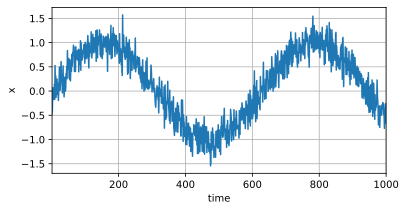

In [3]:
data = Data()
d2l.plot(data.time, data.x, 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

To turn the series into supervised examples,
we adopt the fixed-window strategy with a window of length $\tau$:
the label is $y = x_t$ and the features are
$\mathbf{x}_t = [x_{t-\tau}, \ldots, x_{t-1}]$.
This yields $T - \tau$ examples,
since the first $\tau$ steps lack enough history and we drop them
(padding with zeros is the alternative).
We create a data iterator over the first 600 examples,
covering a bit less than one period of the sine.

In [4]:
@d2l.add_to_class(Data)
def get_dataloader(self, train):
    features = [self.x[i : self.T-self.tau+i] for i in range(self.tau)]
    self.features = d2l.stack(features, 1)
    self.labels = d2l.reshape(self.x[self.tau:], (-1, 1))
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader([self.features, self.labels], train, i)

Our model is a plain linear regression on the $\tau$ lag features,
about the simplest autoregressive model there is.

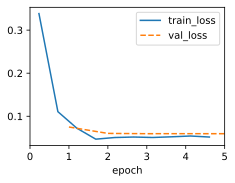

In [5]:
model = d2l.LinearRegression(num_inputs=data.tau, lr=0.01)
trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

## Prediction

### One-Step-Ahead Prediction

First the easy case: predict $\hat{x}_t$ from the *true* previous
$\tau$ values.

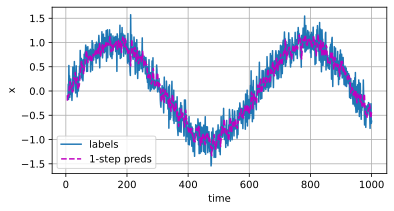

In [6]:
onestep_preds = model(data.features)
d2l.plot(data.time[data.tau:], [data.labels, onestep_preds], 'time', 'x',
         legend=['labels', '1-step preds'], figsize=(6, 3))

These predictions track the series closely, even near the end at $t = 1000$.

### Multistep Rollout

The hard case is forecasting several steps ahead.
Suppose we have observed only up to step 604 (`num_train + tau`)
and want to predict $\hat{x}_{609}$.
We cannot form the one-step input for step 609,
because we have not observed $x_{605}, \ldots, x_{608}$.
The fix is to feed our own predictions back in
as if they were observations, rolling forward one step at a time:

$$\begin{aligned}
\hat{x}_{605} &= f(x_{601}, x_{602}, x_{603}, x_{604}), \\
\hat{x}_{606} &= f(x_{602}, x_{603}, x_{604}, \hat{x}_{605}), \\
\hat{x}_{607} &= f(x_{603}, x_{604}, \hat{x}_{605}, \hat{x}_{606}),\\
\hat{x}_{608} &= f(x_{604}, \hat{x}_{605}, \hat{x}_{606}, \hat{x}_{607}),\\
\hat{x}_{609} &= f(\hat{x}_{605}, \hat{x}_{606}, \hat{x}_{607}, \hat{x}_{608}),\\
&\vdots\end{aligned}$$

For an observed series $x_1, \ldots, x_t$,
the prediction $\hat{x}_{t+k}$ is the $k$*-step-ahead prediction*,
and a rollout chains one-step predictions to reach it.
Let us see how it goes.

In [7]:
multistep_preds = d2l.zeros(data.T)
multistep_preds = multistep_preds.at[:].set(data.x)
for i in range(data.num_train + data.tau, data.T):
    pred = model(d2l.reshape(
        multistep_preds[i-data.tau : i], (1, -1)))
    multistep_preds = multistep_preds.at[i].set(pred.item())

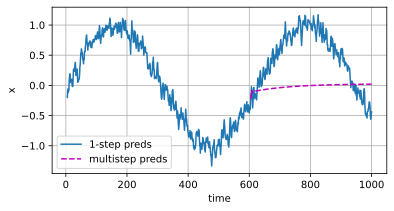

In [8]:
d2l.plot([data.time[data.tau:], data.time[data.num_train+data.tau:]],
         [onestep_preds, multistep_preds[data.num_train+data.tau:]], 'time',
         'x', legend=['1-step preds', 'multistep preds'], figsize=(6, 3))

The forecast collapses to a near-constant within a few steps.
The reason is error accumulation.
Say that after one step we have some error $\epsilon_1 = \bar\epsilon$.
That error now perturbs the *input* of the next step,
so we incur an error of about
$\epsilon_2 = \bar\epsilon + c\,\epsilon_1$ for some constant $c$,
and so on: small mistakes compound as they are fed back,
and the prediction diverges rapidly from the truth.
You have seen this before: a weather forecast is sharp a day out
and nearly useless two weeks out.

To watch the degradation set in, we compute $k$-step predictions
across the whole series for $k = 1, 4, 16, 64$.

In [9]:
def k_step_pred(k):
    features = []
    for i in range(data.tau):
        features.append(data.x[i : i+data.T-data.tau-k+1])
    # The (i+tau)-th element stores the (i+1)-step-ahead predictions
    for i in range(k):
        preds = model(d2l.stack(features[i : i+data.tau], 1))
        features.append(d2l.reshape(preds, -1))
    return features[data.tau:]

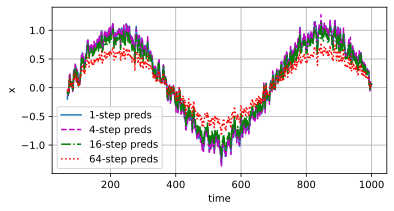

In [10]:
steps = (1, 4, 16, 64)
preds = k_step_pred(steps[-1])
d2l.plot(data.time[data.tau+steps[-1]-1:],
         [d2l.numpy(preds[k-1]) for k in steps], 'time', 'x',
         legend=[f'{k}-step preds' for k in steps], figsize=(6, 3))

The 1- and 4-step forecasts still hug the truth;
the 16-step forecast is visibly damped,
and by 64 steps the accumulated error has shrunk the prediction
to a low-amplitude echo of the real series.

### Why This Matters Everywhere

This compounding is not a quirk of a weak model or a toy series.
It is intrinsic to *any* autoregressive generator
that consumes its own outputs.
A language model that samples one token at a time can drift
off topic or into repetition once a few odd choices
steer it into a region of text it never saw during training;
a learned world model simulating an environment loses coherence
over a long rollout for the same reason.
Two remedies run through the rest of the book.
First, how we turn each conditional into a concrete next value matters:
choosing well at each step (the decoding strategies of
that section) keeps a rollout on the manifold
of realistic sequences far longer than blindly taking the mean or mode.
Second, exposing a model to its own predictions during training,
not only to gold histories,
narrows the gap between the one-step world it is trained in
and the multistep world it is used in.
We return to both.

## Summary

Sequences break the i.i.d. assumption:
entries within a sequence are dependent,
and the values are often nonstationary
even when the underlying dynamics are stationary.
Autoregressive models turn sequence modeling into ordinary
supervised learning by predicting each entry from its predecessors,
either through a fixed window of the last $\tau$ observations
(autoregression, the n-gram idea) or through a recurrent latent state
that summarizes the whole past in bounded memory
(latent autoregression, the RNN idea).
One-step-ahead prediction is comparatively easy;
multistep forecasting must feed predictions back as inputs,
so it accumulates error and degrades quickly.
Respect temporal order when training, never on future data,
and expect extrapolation to be much harder than interpolation.

## Exercises

1. Improve the model in this section's experiment.
    1. Incorporate more than the past four observations. How many do you really need?
    1. How many past observations would you need if there were no noise? Hint: you can write $\sin$ and $\cos$ as a differential equation.
    1. Can you incorporate older observations while keeping the number of features fixed? Does accuracy improve? Why?
    1. Change the network architecture, for instance replacing the linear model with a small MLP, and retrain (possibly for more epochs). What do you observe?
1. For $k \in \{1, 2, 4, 8, 16\}$, plot the average $k$-step-ahead prediction error against $k$. Where does the error curve bend, and how does that compare to the qualitative decay you saw in the plots?
1. Compute the horizon at which the multistep rollout error exceeds the variance of the series itself. What does forecasting past that horizon actually buy you?
1. Replace the single sine with a *regime-switching* series, for example by splicing together two sines of different frequencies. Does one fixed-$\tau$ linear model still fit both regimes? What breaks, and where?
1. An investor picks a stock by looking at its past returns to decide which is likely to do well. What could go wrong with this strategy?
1. Give an example where a latent autoregressive model is clearly needed to capture the dynamics of the data.

[Discussions](https://d2l.discourse.group/t/18010)